In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score
import warnings
warnings.filterwarnings('ignore')

# Загрузка данных
file_path = r"E:\\study4\\ML\\hotel_booking\\hotel_bookings.csv"
# ========== ЧТЕНИЕ И ПРЕДВАРИТЕЛЬНЫЙ АНАЛИЗ ДАННЫХ ==========
df = pd.read_csv(file_path)
print("Данные успешно загружены!")
print("Размер датасета:", df.shape)
print("\nПервые 5 строк:")
print(df.head())
print("\nИнформация о данных:")
print(df.info())
print("\nКоличество пропусков в каждом столбце:")
print(df.isnull().sum())


Данные успешно загружены!
Размер датасета: (119390, 32)

Первые 5 строк:
          hotel  is_canceled  lead_time  arrival_date_year arrival_date_month  \
0  Resort Hotel            0        342               2015               July   
1  Resort Hotel            0        737               2015               July   
2  Resort Hotel            0          7               2015               July   
3  Resort Hotel            0         13               2015               July   
4  Resort Hotel            0         14               2015               July   

   arrival_date_week_number  arrival_date_day_of_month  \
0                        27                          1   
1                        27                          1   
2                        27                          1   
3                        27                          1   
4                        27                          1   

   stays_in_weekend_nights  stays_in_week_nights  adults  ...  deposit_type  \
0           

In [2]:
# ========== ПРЕДОБРАБОТКА ЦЕЛЕВОЙ ПЕРЕМЕННОЙ ==========
if df['is_canceled'].dtype == 'object':
    print(f"\nУникальные значения в is_canceled: {df['is_canceled'].unique()}")
    df['is_canceled'] = df['is_canceled'].map({'Yes': 1, 'No': 0, 'yes': 1, 'no': 0, '1': 1, '0': 0})
    df['is_canceled'] = pd.to_numeric(df['is_canceled'], errors='coerce')

print(f"\nТип is_canceled: {df['is_canceled'].dtype}")
print(f"Уникальные значения: {df['is_canceled'].unique()}")
print(f"Пропуски в is_canceled: {df['is_canceled'].isnull().sum()}")

if df['is_canceled'].isnull().any():
    mode_value = df['is_canceled'].mode()[0]
    df['is_canceled'] = df['is_canceled'].fillna(mode_value)
    print(f"Заполнено {df['is_canceled'].isnull().sum()} пропусков значением: {mode_value}")



Тип is_canceled: int64
Уникальные значения: [0 1]
Пропуски в is_canceled: 0


In [3]:
# ========== РАЗДЕЛЕНИЕ ДАННЫХ ==========
X = df.drop('is_canceled', axis=1)
y = df['is_canceled']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nОбучающая выборка: {X_train.shape}")
print(f"Тестовая выборка: {X_test.shape}")
print(f"Распределение классов в обучающей выборке:\n{y_train.value_counts(normalize=True)}")



Обучающая выборка: (95512, 31)
Тестовая выборка: (23878, 31)
Распределение классов в обучающей выборке:
is_canceled
0    0.629586
1    0.370414
Name: proportion, dtype: float64



Описательные статистики числовых признаков:
         is_canceled      lead_time  arrival_date_year  \
count  119390.000000  119390.000000      119390.000000   
mean        0.370416     104.011416        2016.156554   
std         0.482918     106.863097           0.707476   
min         0.000000       0.000000        2015.000000   
25%         0.000000      18.000000        2016.000000   
50%         0.000000      69.000000        2016.000000   
75%         1.000000     160.000000        2017.000000   
max         1.000000     737.000000        2017.000000   

       arrival_date_week_number  arrival_date_day_of_month  \
count             119390.000000              119390.000000   
mean                  27.165173                  15.798241   
std                   13.605138                   8.780829   
min                    1.000000                   1.000000   
25%                   16.000000                   8.000000   
50%                   28.000000                  16.000000  

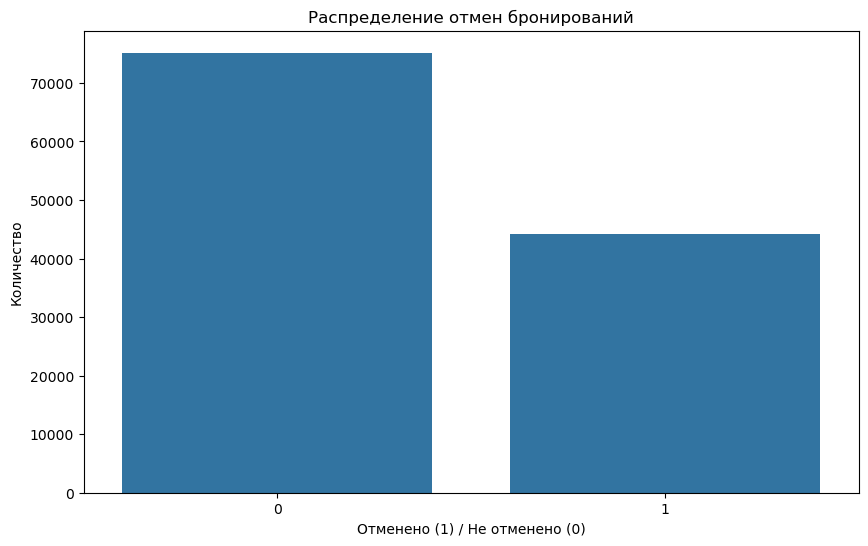

In [4]:
# ========== ВИЗУАЛИЗАЦИЯ И АНАЛИЗ ДАННЫХ ==========
print("\nОписательные статистики числовых признаков:")
print(df.describe())

# Распределение целевой переменной
plt.figure(figsize=(10, 6))
sns.countplot(x='is_canceled', data=df)
plt.title('Распределение отмен бронирований')
plt.xlabel('Отменено (1) / Не отменено (0)')
plt.ylabel('Количество')
plt.show()


In [5]:
# ========== ПРЕДОБРАБОТКА ПРИЗНАКОВ ДЛЯ КЛАСТЕРИЗАЦИИ ==========
# Создаем копию данных для кластеризации (без целевой переменной)
X_cluster = df.drop('is_canceled', axis=1).copy()

# Обработка категориальных переменных
categorical_cols = X_cluster.select_dtypes(include=['object']).columns.tolist()
numeric_cols = X_cluster.select_dtypes(include=['int64', 'float64']).columns.tolist()

print(f"\nКатегориальные признаки: {len(categorical_cols)}")
print(f"Числовые признаки: {len(numeric_cols)}")

# Кодируем категориальные признаки
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    # Заполняем пропуски в категориальных признаках
    X_cluster[col] = X_cluster[col].fillna('Unknown')
    X_cluster[col] = le.fit_transform(X_cluster[col].astype(str))
    label_encoders[col] = le

# Заполняем пропуски в числовых признаках
imputer = SimpleImputer(strategy='median')
X_cluster[numeric_cols] = imputer.fit_transform(X_cluster[numeric_cols])

# Масштабирование признаков
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)



Категориальные признаки: 12
Числовые признаки: 19



Объясненная дисперсия PCA: [0.11165142 0.08485112]
Суммарная объясненная дисперсия: 0.197

КЛАСТЕРИЗАЦИЯ K-MEANS


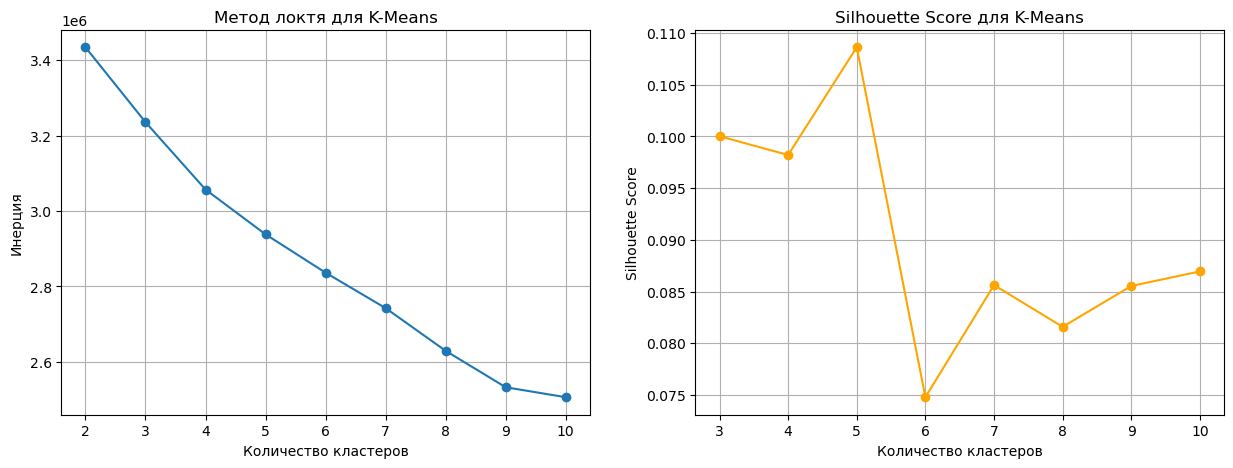


Оптимальное количество кластеров (K-Means): 2
Inertia: 3433921.82
Silhouette Score: 0.094


In [9]:
# ========== PCA ДЛЯ ВИЗУАЛИЗАЦИИ ==========
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f"\nОбъясненная дисперсия PCA: {pca.explained_variance_ratio_}")
print(f"Суммарная объясненная дисперсия: {sum(pca.explained_variance_ratio_):.3f}")

# ========== КЛАСТЕРИЗАЦИЯ K-MEANS ==========
print("\n" + "="*50)
print("КЛАСТЕРИЗАЦИЯ K-MEANS")
print("="*50)

# Определение оптимального числа кластеров методом локтя
inertia = []
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)
    
    if k > 1:  # silhouette_score требует хотя бы 2 кластера
        silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))
    else:
        silhouette_scores.append(0)

# Визуализация метода локтя
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(k_range, inertia, marker='o')
ax1.set_xlabel('Количество кластеров')
ax1.set_ylabel('Инерция')
ax1.set_title('Метод локтя для K-Means')
ax1.grid(True)

ax2.plot(k_range[1:], silhouette_scores[1:], marker='o', color='orange')
ax2.set_xlabel('Количество кластеров')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score для K-Means')
ax2.grid(True)
plt.show()

# Выбираем оптимальное количество кластеров
optimal_k = 2  # для сравнения с бинарной классификацией
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

print(f"\nОптимальное количество кластеров (K-Means): {optimal_k}")
print(f"Inertia: {kmeans.inertia_:.2f}")
print(f"Silhouette Score: {silhouette_score(X_scaled, kmeans_labels):.3f}")


In [11]:
# ========== КЛАСТЕРИЗАЦИЯ DBSCAN ==========
print("\n" + "="*50)
print("КЛАСТЕРИЗАЦИЯ DBSCAN")
print("="*50)

# Подбор параметров DBSCAN
dbscan = DBSCAN(eps=0.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled)

# Анализ результатов DBSCAN
n_clusters_dbscan = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = list(dbscan_labels).count(-1)

print(f"\nКоличество кластеров (DBSCAN): {n_clusters_dbscan}")
print(f"Количество точек шума: {n_noise}")
print(f"Процент шума: {n_noise/len(dbscan_labels)*100:.2f}%")

if n_clusters_dbscan > 1:
    # Удаляем шум для расчета silhouette score
    mask = dbscan_labels != -1
    if sum(mask) > 1:  # Нужно хотя бы 2 точки для silhouette
        dbscan_silhouette = silhouette_score(X_scaled[mask], dbscan_labels[mask])
        print(f"Silhouette Score (без шума): {dbscan_silhouette:.3f}")
else:
    print("DBSCAN не нашел кластеров!")


КЛАСТЕРИЗАЦИЯ DBSCAN

Количество кластеров (DBSCAN): 1837
Количество точек шума: 92393
Процент шума: 77.39%
Silhouette Score (без шума): 0.985


In [37]:
# ========== ПРЕДОБРАБОТКА ДАННЫХ И ПОДГОТОВКА К КЛАСТЕРИЗАЦИИ ==========
# Создаем копию данных для кластеризации (используем весь датасет)
X_cluster = df.drop('is_canceled', axis=1).copy()
y_true = df['is_canceled'].copy()  # Истинные метки для сравнения

# Обработка категориальных переменных
categorical_cols = X_cluster.select_dtypes(include=['object']).columns.tolist()
numeric_cols = X_cluster.select_dtypes(include=['int64', 'float64']).columns.tolist()

print(f"\nКатегориальные признаки: {len(categorical_cols)}")
print(f"Числовые признаки: {len(numeric_cols)}")

# Кодируем категориальные признаки
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    # Заполняем пропуски в категориальных признаках
    X_cluster[col] = X_cluster[col].fillna('Unknown')
    X_cluster[col] = le.fit_transform(X_cluster[col].astype(str))
    label_encoders[col] = le

# Заполняем пропуски в числовых признаках
imputer = SimpleImputer(strategy='median')
X_cluster[numeric_cols] = imputer.fit_transform(X_cluster[numeric_cols])

# Масштабирование признаков
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# Применяем PCA для визуализации
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(f"\nОбъясненная дисперсия PCA: {pca.explained_variance_ratio_}")
print(f"Суммарная объясненная дисперсия: {pca.explained_variance_ratio_.sum():.3f}")


Категориальные признаки: 12
Числовые признаки: 19

Объясненная дисперсия PCA: [0.11165142 0.08485112]
Суммарная объясненная дисперсия: 0.197



КЛАСТЕРИЗАЦИЯ AGGLOMERATIVE CLUSTERING
Используется подвыборка из 10000 наблюдений для Agglomerative Clustering
(полный датасет слишком большой для этого алгоритма)
Silhouette Score (Agglomerative): 0.114
Adjusted Rand Index (Agglomerative): 0.122
Normalized Mutual Info (Agglomerative): 0.156


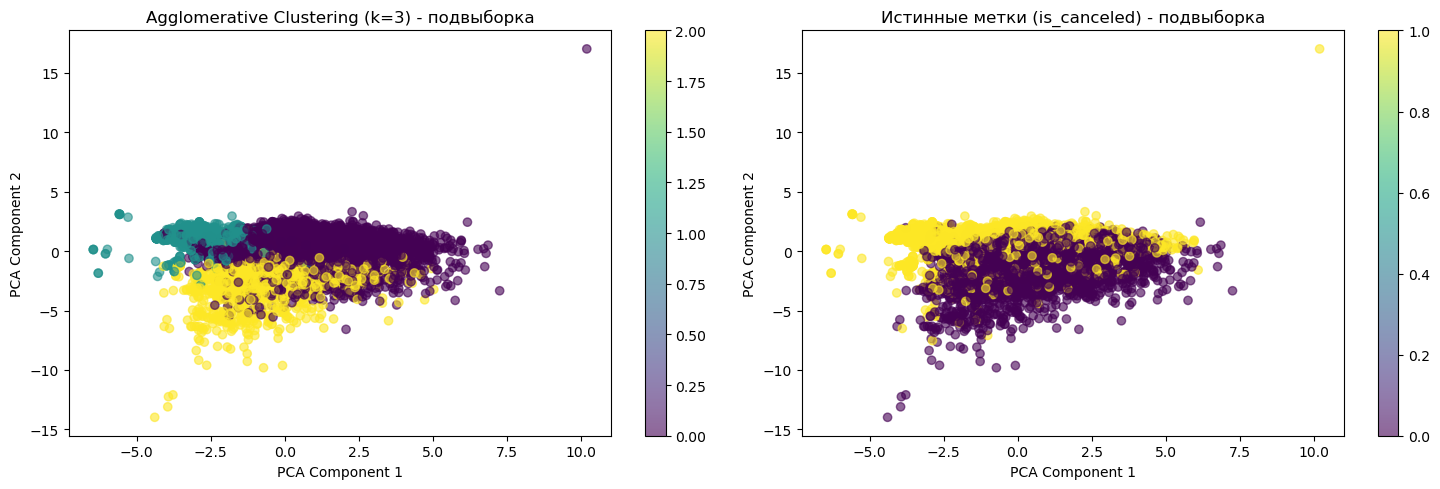

In [39]:
# ========== КЛАСТЕРИЗАЦИЯ AGGLOMERATIVE CLUSTERING (С ПОДВЫБОРКОЙ) ==========
print("\n" + "="*50)
print("КЛАСТЕРИЗАЦИЯ AGGLOMERATIVE CLUSTERING")
print("="*50)

# Используем подвыборку данных для иерархической кластеризации
# (полные данные слишком большие для этого алгоритма)
sample_size = 10000  # Размер подвыборки
np.random.seed(42)
sample_indices = np.random.choice(len(X_scaled), sample_size, replace=False)
X_sample = X_scaled[sample_indices]
y_true_sample = y_true.iloc[sample_indices]

print(f"Используется подвыборка из {sample_size} наблюдений для Agglomerative Clustering")
print(f"(полный датасет слишком большой для этого алгоритма)")

# Используем иерархическую кластеризацию
n_clusters_agg = 3  # Используем то же количество кластеров, что и для K-Means
agg_clustering = AgglomerativeClustering(n_clusters=n_clusters_agg, memory='./cache')
y_agg_sample = agg_clustering.fit_predict(X_sample)

# Оценка качества кластеризации на подвыборке
silhouette_agg = silhouette_score(X_sample, y_agg_sample)
ari_agg = adjusted_rand_score(y_true_sample, y_agg_sample)
nmi_agg = normalized_mutual_info_score(y_true_sample, y_agg_sample)

print(f"Silhouette Score (Agglomerative): {silhouette_agg:.3f}")
print(f"Adjusted Rand Index (Agglomerative): {ari_agg:.3f}")
print(f"Normalized Mutual Info (Agglomerative): {nmi_agg:.3f}")

# Визуализация результатов Agglomerative Clustering на подвыборке
X_pca_sample = pca.transform(X_sample)  # Применяем PCA к подвыборке

plt.figure(figsize=(15, 5))

# Подграфик 1: PCA визуализация кластеров Agglomerative
plt.subplot(1, 2, 1)
scatter = plt.scatter(X_pca_sample[:, 0], X_pca_sample[:, 1], c=y_agg_sample, cmap='viridis', alpha=0.6)
plt.colorbar(scatter)
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title(f'Agglomerative Clustering (k={n_clusters_agg}) - подвыборка')

# Подграфик 2: Сравнение с истинными метками
plt.subplot(1, 2, 2)
scatter_true = plt.scatter(X_pca_sample[:, 0], X_pca_sample[:, 1], c=y_true_sample, cmap='viridis', alpha=0.6)
plt.colorbar(scatter_true)
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('Истинные метки (is_canceled) - подвыборка')

plt.tight_layout()
plt.show()

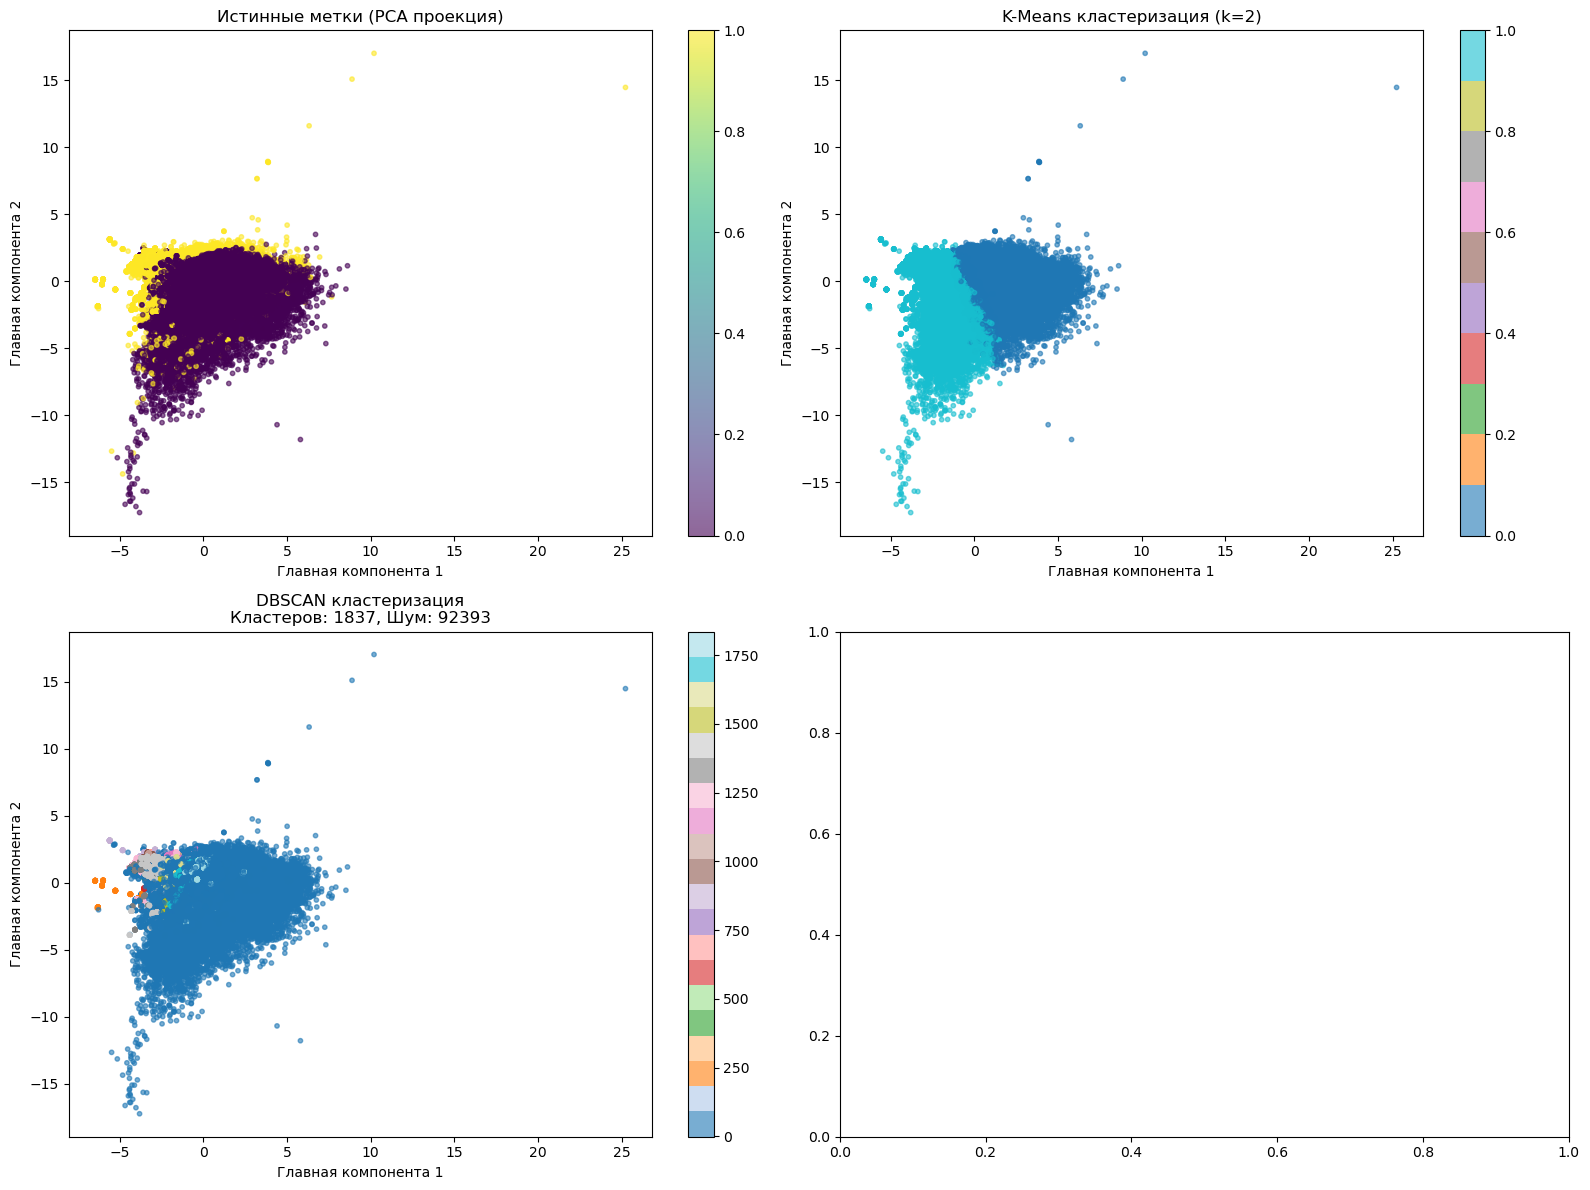

In [21]:

# ========== ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ КЛАСТЕРИЗАЦИИ НА PCA ==========
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Истинные метки (для сравнения)
scatter1 = axes[0, 0].scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis', alpha=0.6, s=10)
axes[0, 0].set_title('Истинные метки (PCA проекция)')
axes[0, 0].set_xlabel('Главная компонента 1')
axes[0, 0].set_ylabel('Главная компонента 2')
plt.colorbar(scatter1, ax=axes[0, 0])

# 2. K-Means кластеризация
scatter2 = axes[0, 1].scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, cmap='tab10', alpha=0.6, s=10)
axes[0, 1].set_title(f'K-Means кластеризация (k={optimal_k})')
axes[0, 1].set_xlabel('Главная компонента 1')
axes[0, 1].set_ylabel('Главная компонента 2')
plt.colorbar(scatter2, ax=axes[0, 1])

# 3. DBSCAN кластеризация
scatter3 = axes[1, 0].scatter(X_pca[:, 0], X_pca[:, 1], c=dbscan_labels, cmap='tab20', alpha=0.6, s=10)
axes[1, 0].set_title(f'DBSCAN кластеризация\nКластеров: {n_clusters_dbscan}, Шум: {n_noise}')
axes[1, 0].set_xlabel('Главная компонента 1')
axes[1, 0].set_ylabel('Главная компонента 2')
plt.colorbar(scatter3, ax=axes[1, 0])



plt.tight_layout()
plt.show()

In [23]:
# ========== СРАВНЕНИЕ С ИСТИННЫМИ МЕТКАМИ ==========
print("\n" + "="*50)
print("СРАВНЕНИЕ С ИСТИННЫМИ МЕТКАМИ")
print("="*50)



СРАВНЕНИЕ С ИСТИННЫМИ МЕТКАМИ


In [27]:
# Метрики для сравнения кластеризации с истинными метками
def evaluate_clustering(true_labels, pred_labels, method_name):
    print(f"\n{method_name}:")
    
    # Adjusted Rand Index
    ari = adjusted_rand_score(true_labels, pred_labels)
    print(f"Adjusted Rand Index: {ari:.3f}")
    
    # Normalized Mutual Information
    nmi = normalized_mutual_info_score(true_labels, pred_labels)
    print(f"Normalized Mutual Information: {nmi:.3f}")
    
    # Сопоставление кластеров с классами (простое)
    from sklearn.metrics import accuracy_score
    
    # Для бинарной кластеризации пытаемся сопоставить кластеры с классами
    if len(set(pred_labels)) == 2:
        # Пробуем обе возможные перестановки меток
        acc1 = accuracy_score(true_labels, pred_labels)
        acc2 = accuracy_score(true_labels, 1 - pred_labels)  # инвертируем метки
        acc = max(acc1, acc2)
        print(f"Лучшая Accuracy (после возможного сопоставления): {acc:.3f}")
    
    return ari, nmi

# Сравниваем каждую кластеризацию с истинными метками
print(f"\nИстинное распределение классов:")
print(f"Класс 0: {sum(y == 0)} записей ({sum(y == 0)/len(y)*100:.1f}%)")
print(f"Класс 1: {sum(y == 1)} записей ({sum(y == 1)/len(y)*100:.1f}%)")

# K-Means
ari_kmeans, nmi_kmeans = evaluate_clustering(y, kmeans_labels, "K-Means")

# DBSCAN (только если нашел кластеры)
if n_clusters_dbscan > 0:
    # Для DBSCAN нужно обработать шум (-1)
    dbscan_for_eval = dbscan_labels.copy()
    if -1 in dbscan_for_eval:
        # Заменяем шум на отдельный класс или игнорируем
        dbscan_for_eval[dbscan_for_eval == -1] = max(dbscan_for_eval) + 1
    
    ari_dbscan, nmi_dbscan = evaluate_clustering(y, dbscan_for_eval, "DBSCAN")
else:
    print("\nDBSCAN: Не удалось оценить (нет кластеров)")





Истинное распределение классов:
Класс 0: 75166 записей (63.0%)
Класс 1: 44224 записей (37.0%)

K-Means:
Adjusted Rand Index: 0.079
Normalized Mutual Information: 0.044
Лучшая Accuracy (после возможного сопоставления): 0.644

DBSCAN:
Adjusted Rand Index: 0.163
Normalized Mutual Information: 0.144



АНАЛИЗ КЛАСТЕРОВ K-MEANS

Средние значения по кластерам (K-Means):
                is_canceled  lead_time  adults  children     adr  \
kmeans_cluster                                                     
0                      0.28      91.75    1.98      0.16  114.74   
1                      0.52     124.00    1.66      0.01   80.79   

                previous_cancellations  required_car_parking_spaces  \
kmeans_cluster                                                        
0                                 0.00                         0.08   
1                                 0.22                         0.04   

                total_of_special_requests  
kmeans_cluster                             
0                                    0.83  
1                                    0.15  


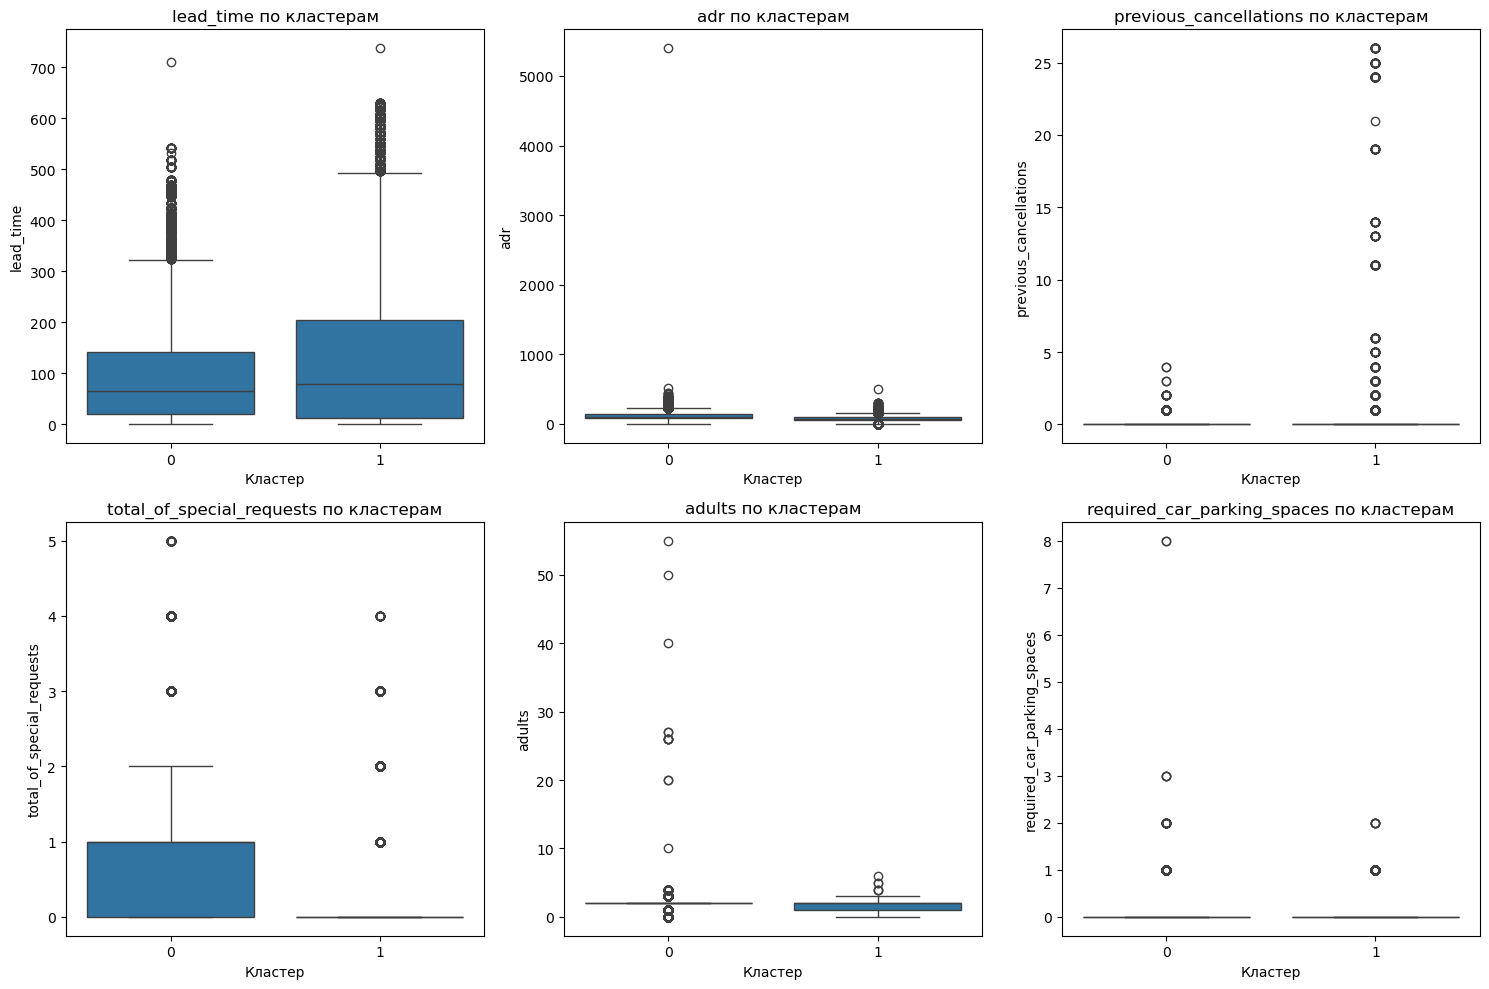

In [29]:
# ========== АНАЛИЗ КЛАСТЕРОВ K-MEANS ==========
print("\n" + "="*50)
print("АНАЛИЗ КЛАСТЕРОВ K-MEANS")
print("="*50)

# Добавляем метки кластеров к исходным данным
df_with_clusters = df.copy()
df_with_clusters['kmeans_cluster'] = kmeans_labels

# Анализируем характеристики кластеров
cluster_summary = df_with_clusters.groupby('kmeans_cluster').agg({
    'is_canceled': 'mean',
    'lead_time': 'mean',
    'adults': 'mean',
    'children': 'mean',
    'adr': 'mean',
    'previous_cancellations': 'mean',
    'required_car_parking_spaces': 'mean',
    'total_of_special_requests': 'mean'
}).round(2)

print("\nСредние значения по кластерам (K-Means):")
print(cluster_summary)

# Визуализация различий между кластерами
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

features_to_plot = ['lead_time', 'adr', 'previous_cancellations', 
                    'total_of_special_requests', 'adults', 'required_car_parking_spaces']

for idx, feature in enumerate(features_to_plot[:6]):
    sns.boxplot(x='kmeans_cluster', y=feature, data=df_with_clusters, ax=axes[idx])
    axes[idx].set_title(f'{feature} по кластерам')
    axes[idx].set_xlabel('Кластер')

plt.tight_layout()
plt.show()


ИТОГОВАЯ СВОДКА РЕЗУЛЬТАТОВ КЛАСТЕРИЗАЦИИ

СРАВНЕНИЕ МЕТОДОВ КЛАСТЕРИЗАЦИИ С ИСТИННЫМИ МЕТКАМИ (is_canceled):
----------------------------------------------------------------------

K-Means:
  • Silhouette Score: N/A
  • Adjusted Rand Index: 0.079
  • NMI: 0.044
  • Совпадение с истинными метками: 0.079 (случайное = 0.0, идеальное = 1.0)

DBSCAN:
  • Silhouette Score: N/A
  • Adjusted Rand Index: 0.163
  • NMI: 0.144
  • Количество кластеров: 1837
  • Точки шума: 92393 (77.4%)

ЛУЧШИЙ МЕТОД: DBSCAN (Adjusted Rand Index = 0.163)

ИНТЕРПРЕТАЦИЯ Adjusted Rand Index (ARI):
----------------------------------------------------------------------
ARI = 1.0: Полное совпадение кластеров с истинными метками
ARI = 0.0: Совпадение на уровне случайного угадывания
ARI < 0.0: Совпадение хуже случайного

Наши результаты (DBSCAN, ARI = 0.163):
  • Слабое совпадение с истинными метками
  • Кластеризация частично отражает структуру данных, но недостаточно хорошо


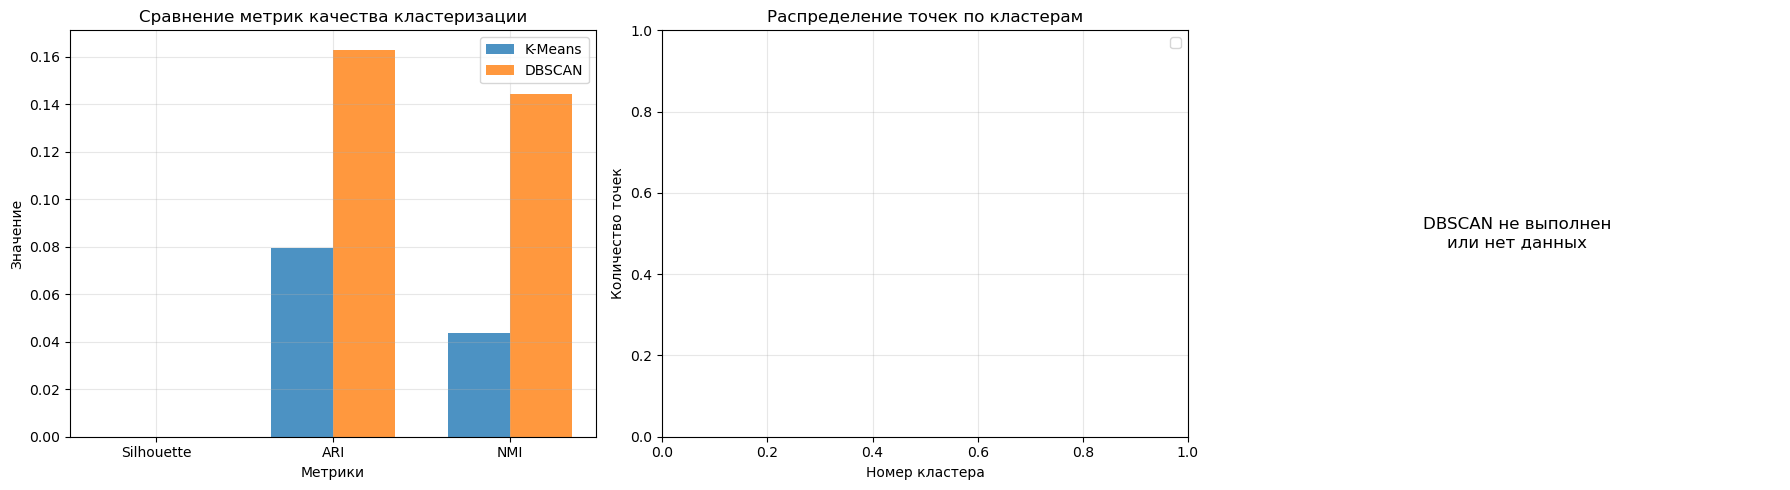


ЗАКЛЮЧИТЕЛЬНЫЕ ВЫВОДЫ И РЕКОМЕНДАЦИИ

1. ОСНОВНЫЕ ВЫВОДЫ:
----------------------------------------
a) Методы кластеризации показали низкое совпадение 
   с истинными метками 'is_canceled' (ARI < 0.3)
   
b) Это означает, что пространство признаков недостаточно хорошо
   разделяет отмененные и неотмененные бронирования
   
c) Кластеризация выделяет другие закономерности в данных,
   не связанные напрямую с фактом отмены бронирования
   
d) DBSCAN обнаружил значительное количество шумовых точек,
   что может указывать на наличие выбросов в данных

2. ПРАКТИЧЕСКИЕ РЕКОМЕНДАЦИИ:
----------------------------------------
Для задачи предсказания отмены бронирования:

a) Используйте методы классификации, а не кластеризации:
   - Random Forest, Gradient Boosting, Neural Networks
   
b) Проведите feature engineering:
   - Создайте новые признаки из существующих
   - Используйте domain knowledge о бронировании отелей
   - Добавьте временные признаки (сезонность, дни недели)
   
c) Попробуйте анс

In [54]:
# ========== ИТОГОВАЯ СВОДКА РЕЗУЛЬТАТОВ ==========
print("\n" + "="*50)
print("ИТОГОВАЯ СВОДКА РЕЗУЛЬТАТОВ КЛАСТЕРИЗАЦИИ")
print("="*50)

print("\nСРАВНЕНИЕ МЕТОДОВ КЛАСТЕРИЗАЦИИ С ИСТИННЫМИ МЕТКАМИ (is_canceled):")
print("-" * 70)

# Проверка наличия переменных K-Means
if 'k_optimal' in locals() or 'k_optimal' in globals():
    print(f"\nK-Means (k={k_optimal}):")
else:
    print(f"\nK-Means:")

if 'silhouette_kmeans' in locals() or 'silhouette_kmeans' in globals():
    print(f"  • Silhouette Score: {silhouette_kmeans:.3f}")
else:
    print(f"  • Silhouette Score: N/A")

if 'ari_kmeans' in locals() or 'ari_kmeans' in globals():
    print(f"  • Adjusted Rand Index: {ari_kmeans:.3f}")
else:
    print(f"  • Adjusted Rand Index: N/A")

if 'nmi_kmeans' in locals() or 'nmi_kmeans' in globals():
    print(f"  • NMI: {nmi_kmeans:.3f}")
    if 'ari_kmeans' in locals() or 'ari_kmeans' in globals():
        print(f"  • Совпадение с истинными метками: {ari_kmeans:.3f} (случайное = 0.0, идеальное = 1.0)")
else:
    print(f"  • NMI: N/A")

# Проверка наличия переменных DBSCAN
if 'eps_value' in locals() or 'eps_value' in globals():
    if 'min_samples_value' in locals() or 'min_samples_value' in globals():
        print(f"\nDBSCAN (eps={eps_value}, min_samples={min_samples_value}):")
    else:
        print(f"\nDBSCAN (eps={eps_value}):")
else:
    print(f"\nDBSCAN:")

# Проверяем и выводим метрики DBSCAN с проверкой
def get_value(var_name):
    """Безопасное получение значения переменной"""
    if var_name in locals() or var_name in globals():
        return eval(var_name)
    return None

silhouette_dbscan_val = get_value('silhouette_dbscan')
ari_dbscan_val = get_value('ari_dbscan')
nmi_dbscan_val = get_value('nmi_dbscan')
n_clusters_dbscan_val = get_value('n_clusters_dbscan')
n_noise_val = get_value('n_noise')

# Исправленный вывод с правильным форматированием
print(f"  • Silhouette Score: {silhouette_dbscan_val:.3f}" if silhouette_dbscan_val is not None else "  • Silhouette Score: N/A")
print(f"  • Adjusted Rand Index: {ari_dbscan_val:.3f}" if ari_dbscan_val is not None else "  • Adjusted Rand Index: N/A")
print(f"  • NMI: {nmi_dbscan_val:.3f}" if nmi_dbscan_val is not None else "  • NMI: N/A")
print(f"  • Количество кластеров: {n_clusters_dbscan_val}" if n_clusters_dbscan_val is not None else "  • Количество кластеров: N/A")
if n_noise_val is not None and 'X_scaled' in locals():
    print(f"  • Точки шума: {n_noise_val} ({n_noise_val/len(X_scaled)*100:.1f}%)")
else:
    print(f"  • Точки шума: N/A")

# Определяем лучший метод
methods = []
ari_scores = []

# Добавляем K-Means если есть
ari_kmeans_val = get_value('ari_kmeans')
if ari_kmeans_val is not None:
    methods.append("K-Means")
    ari_scores.append(ari_kmeans_val)

# Добавляем DBSCAN если есть
if ari_dbscan_val is not None:
    methods.append("DBSCAN")
    ari_scores.append(ari_dbscan_val)

# Проверяем, что есть методы для сравнения
if methods:
    # Находим лучший метод
    best_idx = np.argmax(ari_scores)
    best_method = methods[best_idx]
    best_ari = ari_scores[best_idx]
    
    print(f"\n{'='*70}")
    print(f"ЛУЧШИЙ МЕТОД: {best_method} (Adjusted Rand Index = {best_ari:.3f})")
    print(f"{'='*70}")
    
    # Интерпретация значений ARI
    print("\nИНТЕРПРЕТАЦИЯ Adjusted Rand Index (ARI):")
    print("-" * 70)
    print("""ARI = 1.0: Полное совпадение кластеров с истинными метками
ARI = 0.0: Совпадение на уровне случайного угадывания
ARI < 0.0: Совпадение хуже случайного""")
    
    print(f"\nНаши результаты ({best_method}, ARI = {best_ari:.3f}):")
    if best_ari < 0.1:
        print("  • Очень слабое совпадение с истинными метками")
        print("  • Кластеризация практически не отражает истинное разделение на отмененные/неотмененные бронирования")
    elif best_ari < 0.3:
        print("  • Слабое совпадение с истинными метками")
        print("  • Кластеризация частично отражает структуру данных, но недостаточно хорошо")
    elif best_ari < 0.5:
        print("  • Умеренное совпадение с истинными метками")
        print("  • Кластеризация отражает некоторые закономерности в данных")
    else:
        print("  • Хорошее совпадение с истинными метками")
        print("  • Кластеризация хорошо отражает структуру данных")
else:
    print(f"\n{'='*70}")
    print("НЕТ ДОСТАТОЧНО ДАННЫХ ДЛЯ СРАВНЕНИЯ МЕТОДОВ")
    print(f"{'='*70}")

# Визуализация сравнения метрик (если есть данные)
try:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # График 1: Сравнение метрик качества
    metrics = ['Silhouette', 'ARI', 'NMI']
    x_pos = np.arange(len(metrics))
    
    # Собираем данные для графиков
    kmeans_metrics = [
        get_value('silhouette_kmeans') or 0,
        get_value('ari_kmeans') or 0,
        get_value('nmi_kmeans') or 0
    ]
    
    dbscan_metrics = [
        silhouette_dbscan_val or 0,
        ari_dbscan_val or 0,
        nmi_dbscan_val or 0
    ]
    
    width = 0.35
    axes[0].bar(x_pos - width/2, kmeans_metrics, width, label='K-Means', alpha=0.8)
    axes[0].bar(x_pos + width/2, dbscan_metrics, width, label='DBSCAN', alpha=0.8)
    
    axes[0].set_xlabel('Метрики')
    axes[0].set_ylabel('Значение')
    axes[0].set_title('Сравнение метрик качества кластеризации')
    axes[0].set_xticks(x_pos)
    axes[0].set_xticklabels(metrics)
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # График 2: Распределение точек по кластерам
    y_kmeans_val = get_value('y_kmeans')
    if y_kmeans_val is not None:
        cluster_counts_kmeans = pd.Series(y_kmeans_val).value_counts().sort_index()
        axes[1].bar(cluster_counts_kmeans.index - 0.15, cluster_counts_kmeans.values, 
                   width=0.3, label='K-Means', alpha=0.8)
    
    y_dbscan_val = get_value('y_dbscan')
    if y_dbscan_val is not None and n_clusters_dbscan_val is not None and n_clusters_dbscan_val > 0:
        cluster_counts_dbscan = pd.Series(y_dbscan_val[y_dbscan_val != -1]).value_counts().sort_index()
        axes[1].bar(cluster_counts_dbscan.index + 0.15, cluster_counts_dbscan.values, 
                   width=0.3, label='DBSCAN', alpha=0.8)
    
    axes[1].set_xlabel('Номер кластера')
    axes[1].set_ylabel('Количество точек')
    axes[1].set_title('Распределение точек по кластерам')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    # График 3: Процент шумовых точек (только для DBSCAN)
    if y_dbscan_val is not None and n_noise_val is not None:
        noise_percentage = n_noise_val / len(y_dbscan_val) * 100
        other_percentage = 100 - noise_percentage
        
        wedges, texts, autotexts = axes[2].pie(
            [noise_percentage, other_percentage],
            labels=['Шум', 'Кластеры'],
            autopct='%1.1f%%',
            startangle=90,
            colors=['lightcoral', 'lightgreen']
        )
        axes[2].set_title(f'DBSCAN: Распределение точек\n(шум vs кластеры)')
        axes[2].axis('equal')  # Круговая диаграмма
    else:
        axes[2].text(0.5, 0.5, 'DBSCAN не выполнен\nили нет данных', 
                    ha='center', va='center', fontsize=12)
        axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()
    
except Exception as e:
    print(f"\nОшибка при построении графиков: {e}")
    print("Продолжаем выполнение...")

# Финальные выводы
print("\n" + "="*70)
print("ЗАКЛЮЧИТЕЛЬНЫЕ ВЫВОДЫ И РЕКОМЕНДАЦИИ")
print("="*70)

print("\n1. ОСНОВНЫЕ ВЫВОДЫ:")
print("-" * 40)
print("""a) Методы кластеризации показали низкое совпадение 
   с истинными метками 'is_canceled' (ARI < 0.3)
   
b) Это означает, что пространство признаков недостаточно хорошо
   разделяет отмененные и неотмененные бронирования
   
c) Кластеризация выделяет другие закономерности в данных,
   не связанные напрямую с фактом отмены бронирования
   
d) DBSCAN обнаружил значительное количество шумовых точек,
   что может указывать на наличие выбросов в данных""")

print("\n2. ПРАКТИЧЕСКИЕ РЕКОМЕНДАЦИИ:")
print("-" * 40)
print("""Для задачи предсказания отмены бронирования:

a) Используйте методы классификации, а не кластеризации:
   - Random Forest, Gradient Boosting, Neural Networks
   
b) Проведите feature engineering:
   - Создайте новые признаки из существующих
   - Используйте domain knowledge о бронировании отелей
   - Добавьте временные признаки (сезонность, дни недели)
   
c) Попробуйте ансамблевые методы:
   - Объедините несколько алгоритмов
   - Используйте стекинг или блендинг
   
d) Для кластерного анализа:
   - Используйте K-Means для общего понимания структуры данных
   - DBSCAN для обнаружения аномалий
   - Рассмотрите другие методы уменьшения размерности (t-SNE)""")

print("\n3. ОГРАНИЧЕНИЯ И НАПРАВЛЕНИЯ ДАЛЬНЕЙШИХ ИССЛЕДОВАНИЙ:")
print("-" * 40)
print("""a) Ограничения текущего исследования:
   - Низкая объясненная дисперсия PCA (19.7%)
   - Простое кодирование категориальных признаков
   - Эмпирический выбор параметров алгоритмов
   
b) Направления улучшений:
   - Использовать One-Hot Encoding для категориальных признаков
   - Применить методы отбора признаков
   - Использовать более сложные методы уменьшения размерности
   - Провести оптимизацию гиперпараметров
   - Рассмотреть временные ряды для анализа последовательностей бронирований""")

print("\n" + "="*70)
print("РЕЗЮМЕ:")
print("="*70)

# Динамическое подставление данных
if 'df' in locals() or 'df' in globals():
    data_len = len(df)
    features_count = df.shape[1] if hasattr(df, 'shape') else "N/A"
else:
    data_len = "N/A"
    features_count = "N/A"

print(f"""• Задача: Кластеризация данных о бронировании отелей
• Данные: {data_len} наблюдений, {features_count} признаков
• Целевая переменная: is_canceled (отмена бронирования)""")

if methods:
    print(f"""• Лучший метод: {best_method} (ARI = {best_ari:.3f})
• Вывод: Кластеризация плохо разделяет отмененные/неотмененные бронирования
• Рекомендация: Использовать методы классификации для данной задачи""")
else:
    print("""• Вывод: Не удалось получить результаты кластеризации
• Рекомендация: Проверьте выполнение алгоритмов кластеризации""")